In [1]:
import numpy as np


def generate_flp_instance(num_customers, num_facilities, grid_size=100, setup_cost_range=(50, 200), seed=None):
    """
    Generate an uncapacitated facility location problem instance with integer data.
    
    Parameters:
    -----------
    num_customers : int
        Number of customers to generate.
    num_facilities : int
        Number of potential facility locations to generate.
    grid_size : int, optional
        The size of the 2D square grid (0 to grid_size inclusive for both x and y).
    setup_cost_range : tuple of ints, optional
        Min and max integer values for facility setup costs (inclusive).
    seed : int or None, optional
        Random seed for reproducibility.
    
    Returns:
    --------
    dict
        {
            'customer_coords': np.ndarray of shape (num_customers, 2) with integer coords,
            'facility_coords': np.ndarray of shape (num_facilities, 2) with integer coords,
            'service_costs': np.ndarray of shape (num_customers, num_facilities) with integer costs,
            'setup_costs': np.ndarray of shape (num_facilities,) with integer costs
        }
    """
    if seed is not None:
        np.random.seed(seed)

    # Integer 2D coordinates for customers and facilities
    customer_coords = np.random.randint(0, grid_size + 1, size=(num_customers, 2))
    facility_coords = np.random.randint(0, grid_size + 1, size=(num_facilities, 2))

    # Compute Euclidean distance matrix and round to nearest integer
    diffs = customer_coords[:, None, :] - facility_coords[None, :, :]
    service_costs = np.rint(np.linalg.norm(diffs, axis=2)).astype(int)

    # Integer facility setup costs
    setup_costs = np.random.randint(
        setup_cost_range[0],
        setup_cost_range[1] + 1,
        size=num_facilities
    )

    return {
        'customer_coords': customer_coords,
        'facility_coords': facility_coords,
        'service_costs': service_costs,
        'setup_costs': setup_costs
    }


In [2]:
import matplotlib.pyplot as plt

def plot_flp_instance(instance, show=True):
    """
    Plot customers and facilities for a facility location problem instance.
    
    Parameters:
    -----------
    instance : dict
        Dictionary containing:
            'customer_coords': np.ndarray of shape (num_customers, 2)
            'facility_coords': np.ndarray of shape (num_facilities, 2)
    show : bool, optional
        Whether to display the plot immediately.
    """
    customer_coords = instance['customer_coords']
    facility_coords = instance['facility_coords']
    
    plt.figure(figsize=(8, 8))
    plt.scatter(customer_coords[:, 0], customer_coords[:, 1], marker='o', label='Customers')
    plt.scatter(facility_coords[:, 0], facility_coords[:, 1], marker='s', label='Facilities')
    
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Facility Location Problem Instance')
    plt.legend()
    plt.grid(True)
    
    if show:
        plt.show()

In [3]:
instance = generate_flp_instance(
    num_customers=5,
    num_facilities=2,
    grid_size=100,
    setup_cost_range=(100, 500),
    seed=43
)

print("Customer coordinates:\n", instance['customer_coords'])
print("\nFacility coordinates:\n", instance['facility_coords'])
print("\nFacility setup costs:\n", instance['setup_costs'])
print("\nService cost matrix (customers x facilities):\n", instance['service_costs'])

Customer coordinates:
 [[68 64]
 [49 21]
 [58 16]
 [51 17]
 [59 91]]

Facility coordinates:
 [[66 30]
 [87 64]]

Facility setup costs:
 [391 483]

Service cost matrix (customers x facilities):
 [[34 19]
 [19 57]
 [16 56]
 [20 59]
 [61 39]]


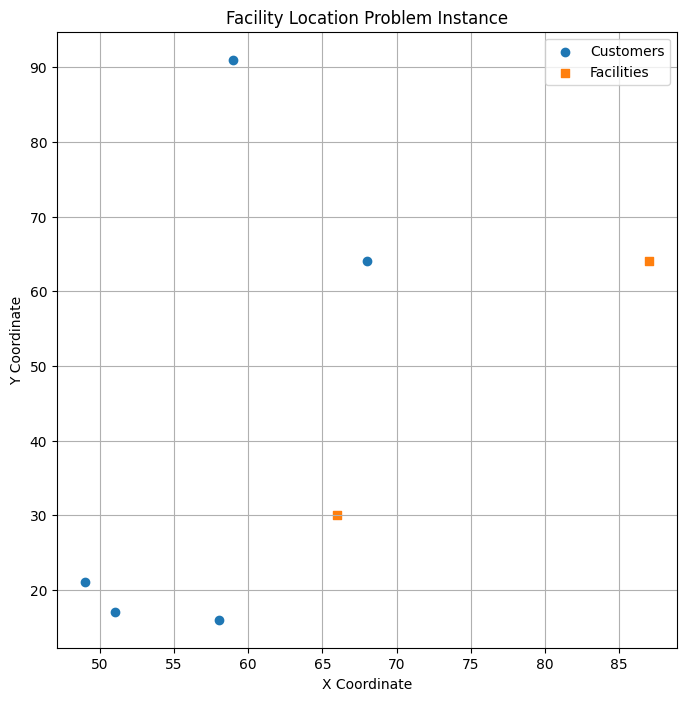

In [4]:
plot_flp_instance(instance)

In [5]:
def plot_flp_solution(instance, x, y, show=True):
    """
    Plot the FLP instance solution, showing opened facilities and customer assignments.
    
    Parameters:
    -----------
    instance : dict
        Dictionary containing:
            'customer_coords': np.ndarray of shape (num_customers, 2)
            'facility_coords': np.ndarray of shape (num_facilities, 2)
    x : np.ndarray of shape (num_customers, num_facilities)
        Binary assignment matrix: x[i, j] = 1 if customer i is served by facility j.
    y : np.ndarray of shape (num_facilities,)
        Binary facility opening vector: y[j] = 1 if facility j is opened.
    show : bool, optional
        Whether to display the plot immediately.
    """
    customer_coords = instance['customer_coords']
    facility_coords = instance['facility_coords']
    
    num_customers, num_facilities = x.shape
    
    plt.figure(figsize=(8, 8))
    
    # Plot all facilities in light gray
    plt.scatter(facility_coords[:, 0], facility_coords[:, 1],
                marker='s', label='Closed Facilities', alpha=0.7)
    
    # Highlight opened facilities
    opened = np.where(y == 1)[0]
    plt.scatter(facility_coords[opened, 0], facility_coords[opened, 1],
                marker='s', label='Opened Facilities', s=100)
    
    # Plot customers
    plt.scatter(customer_coords[:, 0], customer_coords[:, 1],
                marker='o', label='Customers')
    
    # Draw assignment lines
    for i in range(num_customers):
        j = np.argmax(x[i])  # assigned facility
        plt.plot([customer_coords[i, 0], facility_coords[j, 0]],
                 [customer_coords[i, 1], facility_coords[j, 1]],
                 linestyle='--', linewidth=1)
    
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('FLP Solution: Facilities and Assignments')
    plt.legend()
    plt.grid(True)
    
    if show:
        plt.show()

In [7]:
num_facilities

2

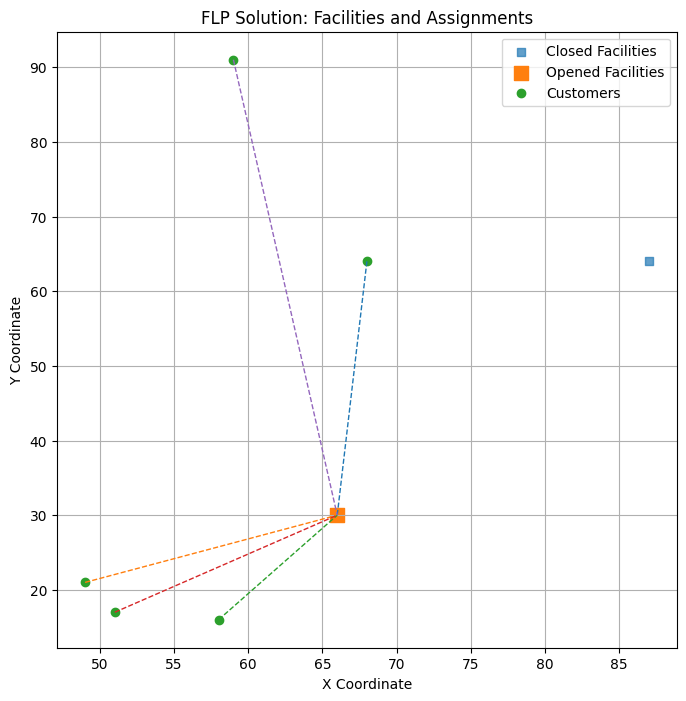

In [10]:
# Create a random feasible solution for demonstration
num_customers, num_facilities = instance['service_costs'].shape
y = np.zeros(num_facilities, dtype=int)
selected = np.random.choice(num_facilities, replace=False)
y[selected] = 1

x = np.zeros((num_customers, num_facilities), dtype=int)
for i in range(num_customers):
    # assign each customer to the nearest opened facility
    costs = instance['service_costs'][i]
    open_costs = np.where(y == 1, costs, np.inf)
    j = np.argmin(open_costs)
    x[i, j] = 1

plot_flp_solution(instance, x, y)

In [11]:
from docplex.mp.model import Model
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.problems import QuadraticProgram

def facility_location_to_quadratic_program(instance: dict) -> QuadraticProgram:
    """
    Convert an uncapacitated facility‐location instance into a QuadraticProgram.
    
    Args:
        instance: dict with keys
            - 'service_costs': np.ndarray of shape (num_customers, num_facilities)
            - 'setup_costs':   np.ndarray of shape (num_facilities,)
    
    Returns:
        A QuadraticProgram encoding the FLP:
            min sum_j f_j y_j + sum_{i,j} c_{ij} x_{ij},
            s.t.  sum_j x_{ij} == 1   for each customer i,
                  x_{ij} <= y_j       for all i,j,
                  x_{ij}, y_j ∈ {0,1}.
    """
    c = instance['service_costs']
    f = instance['setup_costs']
    num_customers, num_facilities = c.shape

    mdl = Model(name="Facility location")
    # Decision variables
    y = {j: mdl.binary_var(name=f"y_{j}") for j in range(num_facilities)}
    x = {
        (i, j): mdl.binary_var(name=f"x_{i}_{j}")
        for i in range(num_customers)
        for j in range(num_facilities)
    }

    # Objective
    mdl.minimize(
        mdl.sum(f[j] * y[j] for j in range(num_facilities)) +
        mdl.sum(c[i, j] * x[(i, j)]
                for i in range(num_customers)
                for j in range(num_facilities))
    )

    # Constraints
    # 1) Each customer i is assigned to exactly one facility
    for i in range(num_customers):
        mdl.add_constraint(
            mdl.sum(x[(i, j)] for j in range(num_facilities)) == 1,
            ctname=f"assign_cust_{i}"
        )

    # 2) Can only assign to an open facility
    for i in range(num_customers):
        for j in range(num_facilities):
            mdl.add_constraint(
                x[(i, j)] <= y[j],
                ctname=f"open_if_assigned_{i}_{j}"
            )

    # Convert to Qiskit QuadraticProgram
    qp: QuadraticProgram = from_docplex_mp(mdl)
    return qp

In [12]:
flp_qp = facility_location_to_quadratic_program(instance)
print(flp_qp.prettyprint())

Problem name: Facility location

Minimize
  34*x_0_0 + 19*x_0_1 + 19*x_1_0 + 57*x_1_1 + 16*x_2_0 + 56*x_2_1 + 20*x_3_0
  + 59*x_3_1 + 61*x_4_0 + 39*x_4_1 + 391*y_0 + 483*y_1

Subject to
  Linear constraints (15)
    x_0_0 + x_0_1 == 1  'assign_cust_0'
    x_1_0 + x_1_1 == 1  'assign_cust_1'
    x_2_0 + x_2_1 == 1  'assign_cust_2'
    x_3_0 + x_3_1 == 1  'assign_cust_3'
    x_4_0 + x_4_1 == 1  'assign_cust_4'
    x_0_0 - y_0 <= 0  'open_if_assigned_0_0'
    x_0_1 - y_1 <= 0  'open_if_assigned_0_1'
    x_1_0 - y_0 <= 0  'open_if_assigned_1_0'
    x_1_1 - y_1 <= 0  'open_if_assigned_1_1'
    x_2_0 - y_0 <= 0  'open_if_assigned_2_0'
    x_2_1 - y_1 <= 0  'open_if_assigned_2_1'
    x_3_0 - y_0 <= 0  'open_if_assigned_3_0'
    x_3_1 - y_1 <= 0  'open_if_assigned_3_1'
    x_4_0 - y_0 <= 0  'open_if_assigned_4_0'
    x_4_1 - y_1 <= 0  'open_if_assigned_4_1'

  Binary variables (12)
    y_0 y_1 x_0_0 x_0_1 x_1_0 x_1_1 x_2_0 x_2_1 x_3_0 x_3_1 x_4_0 x_4_1



In [13]:
coeff_sum = 0
for v in flp_qp._objective._linear.to_dict().values():
    coeff_sum += v

In [14]:
from qiskit_optimization.converters import QuadraticProgramToQubo
conv = QuadraticProgramToQubo(penalty=coeff_sum*2)
flp_qubo = conv.convert(flp_qp)
print(flp_qubo.export_as_lp_string())

/tmp/ipykernel_3852551/2656898339.py:4: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  print(flp_qubo.export_as_lp_string())


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Facility location

Minimize
 obj: 391 y_0 + 483 y_1 - 2474 x_0_0 - 2489 x_0_1 - 2489 x_1_0 - 2451 x_1_1
      - 2492 x_2_0 - 2452 x_2_1 - 2488 x_3_0 - 2449 x_3_1 - 2447 x_4_0
      - 2469 x_4_1 + [ - 5016 y_0*x_0_0 - 5016 y_0*x_1_0 - 5016 y_0*x_2_0
      - 5016 y_0*x_3_0 - 5016 y_0*x_4_0 - 5016 y_1*x_0_1 - 5016 y_1*x_1_1
      - 5016 y_1*x_2_1 - 5016 y_1*x_3_1 - 5016 y_1*x_4_1 + 5016 x_0_0^2
      + 10032 x_0_0*x_0_1 + 5016 x_0_1^2 + 5016 x_1_0^2 + 10032 x_1_0*x_1_1
      + 5016 x_1_1^2 + 5016 x_2_0^2 + 10032 x_2_0*x_2_1 + 5016 x_2_1^2
      + 5016 x_3_0^2 + 10032 x_3_0*x_3_1 + 5016 x_3_1^2 + 5016 x_4_0^2
      + 10032 x_4_0*x_4_1 + 5016 x_4_1^2 ]/2 + 12540
Subject To

Bounds
 0 <= y_0 <= 1
 0 <= y_1 <= 1
 0 <= x_0_0 <= 1
 0 <= x_0_1 <= 1
 0 <= x_1_0 <= 1
 0 <= x_1_1 <= 1
 0 <= x_2_0 <= 1
 0 <= x_2_1 <= 1
 0 <= x_3_0 <= 1
 0 <= x_3_1 <= 1
 0 <= x_4_0 <= 1
 0 <= x_4_1 <= 1

Binaries
 y_0 y_1 x_0_0 x_0_1 x_1_0

In [15]:
Q = flp_qubo.objective.quadratic.to_array()

# Simplify diagonal terms: x^2 = x
# So move diagonal elements to linear and zero them out
linear = flp_qubo.objective.linear.to_array()
diag = np.diag(Q)

# Update linear: x^2 term becomes x
simplified_linear = linear + diag



# Zero out the diagonal in the quadratic matrix
np.fill_diagonal(Q, 0)

# Optional: print simplified objective
print("Simplified linear:", simplified_linear)
print("Simplified quadratic (off-diagonal):\n", Q)

Simplified linear: [391. 483.  34.  19.  19.  57.  16.  56.  20.  59.  61.  39.]
Simplified quadratic (off-diagonal):
 [[    0.     0. -2508.     0. -2508.     0. -2508.     0. -2508.     0.
  -2508.     0.]
 [    0.     0.     0. -2508.     0. -2508.     0. -2508.     0. -2508.
      0. -2508.]
 [    0.     0.     0.  5016.     0.     0.     0.     0.     0.     0.
      0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
      0.     0.]
 [    0.     0.     0.     0.     0.  5016.     0.     0.     0.     0.
      0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
      0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.  5016.     0.     0.
      0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
      0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.  5016.
      0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
      0.

In [16]:
def build_qubo_from_arrays(linear, quadratic, variable_names=None):
    n = len(linear)
    qp = QuadraticProgram()
    
    # If variable names are not given, create default names
    if variable_names is None:
        variable_names = [f'x{i}' for i in range(n)]
    
    # Add binary variables
    for name in variable_names:
        qp.binary_var(name._name)
    
    # Add objective: minimize linear + quadratic terms
    linear_dict = {variable_names[i]._name: linear[i] for i in range(n)}
    
    # Only use upper triangle of Q to avoid double-counting
    quadratic_dict = {}
    for i in range(n):
        for j in range(i + 1, n):
            if quadratic[i, j] != 0:
                quadratic_dict[(variable_names[i]._name, variable_names[j]._name)] = quadratic[i, j]

    max_lin_coeff = max(abs(v) for v in linear_dict.values())
    max_quad_coeff = max(abs(v) for v in quadratic_dict.values())

    if max_lin_coeff > max_quad_coeff:
        linear_dict_normed = {k: v / max_lin_coeff for k, v in linear_dict.items()}
        quadratic_dict_normed = {k: v / max_lin_coeff for k, v in quadratic_dict.items()}
    else:
        linear_dict_normed = {k: v / max_quad_coeff for k, v in linear_dict.items()}
        quadratic_dict_normed = {k: v / max_quad_coeff for k, v in quadratic_dict.items()} 
    
    qp.minimize(linear=linear_dict_normed, quadratic=quadratic_dict_normed)
    
    return qp

In [17]:
flp_simple = build_qubo_from_arrays(simplified_linear, Q, variable_names=flp_qubo.variables)
print(flp_simple.export_as_lp_string())

/tmp/ipykernel_3852551/2843249781.py:2: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  print(flp_simple.export_as_lp_string())


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: CPLEX

Minimize
 obj: 0.077950558214 y_0 + 0.096291866029 y_1 + 0.006778309410 x_0_0
      + 0.003787878788 x_0_1 + 0.003787878788 x_1_0 + 0.011363636364 x_1_1
      + 0.003189792663 x_2_0 + 0.011164274322 x_2_1 + 0.003987240829 x_3_0
      + 0.011762360447 x_3_1 + 0.012161084530 x_4_0 + 0.007775119617 x_4_1 + [
      - y_0*x_0_0 - y_0*x_1_0 - y_0*x_2_0 - y_0*x_3_0 - y_0*x_4_0 - y_1*x_0_1
      - y_1*x_1_1 - y_1*x_2_1 - y_1*x_3_1 - y_1*x_4_1 + 2 x_0_0*x_0_1
      + 2 x_1_0*x_1_1 + 2 x_2_0*x_2_1 + 2 x_3_0*x_3_1 + 2 x_4_0*x_4_1 ]/2
Subject To

Bounds
 0 <= y_0 <= 1
 0 <= y_1 <= 1
 0 <= x_0_0 <= 1
 0 <= x_0_1 <= 1
 0 <= x_1_0 <= 1
 0 <= x_1_1 <= 1
 0 <= x_2_0 <= 1
 0 <= x_2_1 <= 1
 0 <= x_3_0 <= 1
 0 <= x_3_1 <= 1
 0 <= x_4_0 <= 1
 0 <= x_4_1 <= 1

Binaries
 y_0 y_1 x_0_0 x_0_1 x_1_0 x_1_1 x_2_0 x_2_1 x_3_0 x_3_1 x_4_0 x_4_1
End



In [18]:
num_variables = 0
for nam in flp_qubo.variables:
    num_variables +=1
    print(nam._name)

y_0
y_1
x_0_0
x_0_1
x_1_0
x_1_1
x_2_0
x_2_1
x_3_0
x_3_1
x_4_0
x_4_1


In [19]:
def calculate_cost(candidate_bitstring, A, Q):
    if isinstance(candidate_bitstring, str):
        # Convert string to array of ints
        x = np.array([int(bit) for bit in candidate_bitstring])
    elif isinstance(candidate_bitstring, np.ndarray):
        x = candidate_bitstring
    elif isinstance(candidate_bitstring, list):
        # Handle list of strings or ints
        if all(isinstance(bit, str) for bit in candidate_bitstring):
            x = np.array([int(bit) for bit in candidate_bitstring])
        else:
            x = np.array(candidate_bitstring)
    else:
        raise TypeError("Unsupported bitstring type. Must be str, list, or np.ndarray.")

    return x @ Q @ x + A @ x

In [20]:
ising_H = flp_simple.to_ising()[0]
print(ising_H)

SparsePauliOp(['IIIIIIIIIIIZ', 'IIIIIIIIIIZI', 'IIIIIIIIIZII', 'IIIIIIIIZIII', 'IIIIIIIZIIII', 'IIIIIIZIIIII', 'IIIIIZIIIIII', 'IIIIZIIIIIII', 'IIIZIIIIIIII', 'IIZIIIIIIIII', 'IZIIIIIIIIII', 'ZIIIIIIIIIII', 'IIIIIIIIIZIZ', 'IIIIIIIZIIIZ', 'IIIIIZIIIIIZ', 'IIIZIIIIIIIZ', 'IZIIIIIIIIIZ', 'IIIIIIIIZIZI', 'IIIIIIZIIIZI', 'IIIIZIIIIIZI', 'IIZIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIIIZZII', 'IIIIIIZZIIII', 'IIIIZZIIIIII', 'IIZZIIIIIIII', 'ZZIIIIIIIIII'],
              coeffs=[ 0.58602472+0.j,  0.57685407+0.j, -0.12838915+0.j, -0.12689394+0.j,
 -0.12689394+0.j, -0.13068182+0.j, -0.1265949 +0.j, -0.13058214+0.j,
 -0.12699362+0.j, -0.13088118+0.j, -0.13108054+0.j, -0.12888756+0.j,
 -0.125     +0.j, -0.125     +0.j, -0.125     +0.j, -0.125     +0.j,
 -0.125     +0.j, -0.125     +0.j, -0.125     +0.j, -0.125     +0.j,
 -0.125     +0.j, -0.125     +0.j,  0.25      +0.j,  0.25      +0.j,
  0.25      +0.j,  0.25      +0.j,  0.25      +0.j])


In [26]:
num_qubits= ising_H.num_qubits

# AQC annealing

In [21]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Iterable, Optional, Tuple

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate


# ----------------------------
# Annealing circuit utilities
# ----------------------------

def default_schedule_s(step_index: int, num_steps: int) -> float:
    """
    Linear schedule s in [0, 1] at the *start* of step `step_index`.
    If you prefer midpoint-rule, use `use_midpoint=True` in builders below.
    """
    if num_steps <= 0:
        raise ValueError("num_steps must be positive.")
    return step_index / num_steps


def build_driver_x_hamiltonian(num_qubits: int, coeff: float = 1.0) -> SparsePauliOp:
    """H_initial = coeff * sum_i X_i."""
    terms = []
    for i in range(num_qubits):
        pauli = ["I"] * num_qubits
        pauli[i] = "X"
        terms.append("".join(pauli[::-1]))  # Qiskit Pauli strings are right-to-left
    return SparsePauliOp(terms, coeffs=[coeff] * len(terms))


def build_annealing_segment(
    num_qubits: int,
    H_initial: SparsePauliOp,
    H_problem: SparsePauliOp,
    delta_t: float,
    step_start: int,
    step_end: int,
    *,
    schedule_s: Callable[[int, int], float],
    num_steps_total: int,
    s_scale: float = 1.0,
    use_midpoint: bool = False,
    insert_barriers: bool = False,
) -> QuantumCircuit:
    """
    Builds steps [step_start, step_end) of annealing evolution:
        U_k ≈ exp(-i * ((1-s)*H_initial + s*H_problem) * delta_t)
    where s = s_scale * schedule_s(k or k+0.5, num_steps_total).

    Note: if you literally want your current behavior (s *= pi), set s_scale=np.pi.
    """
    if not (0 <= step_start <= step_end <= num_steps_total):
        raise ValueError("Require 0 <= step_start <= step_end <= num_steps_total.")
    if delta_t <= 0:
        raise ValueError("delta_t must be positive.")

    qc = QuantumCircuit(num_qubits)

    for k in range(step_start, step_end):
        k_eff = (k + 0.5) if use_midpoint else k
        s = float(schedule_s(k_eff, num_steps_total)) * float(s_scale)

        # If you want to clamp s into [0,1], uncomment:
        # s = max(0.0, min(1.0, s))

        H_t = (1.0 - s) * H_initial + s * H_problem
        qc.append(PauliEvolutionGate(H_t, time=delta_t), range(num_qubits))

        if insert_barriers:
            qc.barrier()

    return qc


def build_full_trotter_annealing_circuit(
    num_qubits: int,
    H_problem: SparsePauliOp,
    *,
    num_steps: int,
    delta_t: Optional[float] = None,
    H_initial: Optional[SparsePauliOp] = None,
    schedule_s: Callable[[int, int], float] = default_schedule_s,
    s_scale: float = 1.0,
    use_midpoint: bool = False,
    measure: bool = True,
) -> QuantumCircuit:
    """
    Full trotterized annealing circuit with |+...+> initialization.
    """
    if num_steps <= 0:
        raise ValueError("num_steps must be positive.")
    if delta_t is None:
        delta_t = 1.0 / num_steps

    if H_initial is None:
        H_initial = build_driver_x_hamiltonian(num_qubits)

    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))
    qc.barrier()

    seg = build_annealing_segment(
        num_qubits,
        H_initial,
        H_problem,
        delta_t,
        0,
        num_steps,
        schedule_s=schedule_s,
        num_steps_total=num_steps,
        s_scale=s_scale,
        use_midpoint=use_midpoint,
        insert_barriers=False,
    )
    qc.compose(seg, inplace=True)

    qc.barrier()
    if measure:
        qc.measure_all()
    return qc


# ----------------------------
# AQC-Tensor compression glue
# ----------------------------

@dataclass
class AQCSettings:
    """
    Settings for AQC-Tensor optimization (prefix compression).

    Requires:
      pip install 'qiskit-addon-aqc-tensor[aer,quimb-jax]'
    as in IBM tutorial. :contentReference[oaicite:1]{index=1}
    """
    stopping_fidelity: float = 0.999  # stop when fidelity >= this
    maxiter: int = 300
    method: str = "L-BFGS-B"


def aqc_tensor_compress_prefix(
    target_prefix_circuit: QuantumCircuit,
    good_prefix_circuit: QuantumCircuit,
    *,
    aqc_settings: AQCSettings = AQCSettings(),
) -> QuantumCircuit:
    """
    Compress `target_prefix_circuit` into a low-depth ansatz initialized from `good_prefix_circuit`,
    optimizing state fidelity using the AQC-Tensor workflow. :contentReference[oaicite:2]{index=2}
    """
    
    import datetime
    import quimb.tensor
    from scipy.optimize import OptimizeResult, minimize

    from qiskit_addon_aqc_tensor.ansatz_generation import generate_ansatz_from_circuit
    from qiskit_addon_aqc_tensor.objective import MaximizeStateFidelity
    from qiskit_addon_aqc_tensor.simulation.quimb import QuimbSimulator
    from qiskit_addon_aqc_tensor.simulation import tensornetwork_from_circuit
    from qiskit_aer import AerSimulator

    # Simulator settings (same pattern as IBM tutorial)
    # simulator_settings = QuimbSimulator(quimb.tensor.CircuitMPS, autodiff_backend="jax")
    simulator_settings = AerSimulator(method="matrix_product_state",matrix_product_state_max_bond_dimension=100)

    # Build target MPS from the (deep) target prefix
    target_mps = tensornetwork_from_circuit(target_prefix_circuit, simulator_settings)

    # Generate parametrized ansatz + initialization from a shallower "good" prefix
    ansatz, x0 = generate_ansatz_from_circuit(good_prefix_circuit.decompose(reps=4))

    # Optimize parameters to maximize fidelity with target MPS
    stopping_point = 1.0 - float(aqc_settings.stopping_fidelity)
    objective = MaximizeStateFidelity(target_mps, ansatz, simulator_settings)

    def callback(intermediate_result: OptimizeResult):
        fidelity = 1.0 - intermediate_result.fun
        # You can comment this out if you want it quiet:
        print(f"{datetime.datetime.now()}  fidelity={fidelity:.8f}")
        if intermediate_result.fun < stopping_point:
            raise StopIteration

    res = minimize(
        objective,
        x0,
        method=aqc_settings.method,
        jac=True,
        options={"maxiter": int(aqc_settings.maxiter)},
        callback=callback,
    )

    # Accept: success, maxiter, or early StopIteration termination
    if res.status not in (0, 1, 99):
        raise RuntimeError(f"AQC optimization failed: {res.message} (status={res.status})")

    x_final = res.x
    compressed_prefix = ansatz.assign_parameters(x_final, inplace=False)
    return compressed_prefix

def build_annealing_circuit_with_aqc_prefix(
    num_qubits: int,
    H_problem: SparsePauliOp,
    *,
    num_steps: int,
    alpha: int,
    delta_t: Optional[float] = None,
    H_initial: Optional[SparsePauliOp] = None,
    schedule_s: Callable[[int, int], float] = default_schedule_s,
    s_scale: float = 1.0,
    use_midpoint: bool = False,
    aqc_target_refinement: int = 1,
    aqc_good_steps: Optional[int] = None,
    aqc_settings: AQCSettings = AQCSettings(),
    measure: bool = True,
):
    """
    Returns:
        qc: full circuit
        prefix_dict: dict of prefix-related circuits
        remaining_dict: dict of post-prefix / remaining circuits
    """
    if num_steps <= 0:
        raise ValueError("num_steps must be positive.")
    if not (0 <= alpha <= num_steps):
        raise ValueError("alpha must satisfy 0 <= alpha <= num_steps.")
    if delta_t is None:
        delta_t = 1.0 / num_steps
    if H_initial is None:
        H_initial = build_driver_x_hamiltonian(num_qubits)

    prefix_dict = {
        "target_prefix": None,
        "good_prefix": None,
        "compressed_prefix": None,
    }

    remaining_dict = {
        "tail": None,
        "initial_hadamards": None,
        "full_prefix_plus_tail_no_measure": None,
    }

    qc = QuantumCircuit(num_qubits)

    # Initial state prep
    init_circ = QuantumCircuit(num_qubits)
    init_circ.h(range(num_qubits))
    remaining_dict["initial_hadamards"] = init_circ.copy()

    qc.compose(init_circ, inplace=True)
    qc.barrier()

    # --- Build/compress prefix ---
    if alpha > 0:
        if aqc_target_refinement < 1:
            raise ValueError("aqc_target_refinement must be >= 1.")

        refined_steps = alpha * aqc_target_refinement
        refined_dt = delta_t / aqc_target_refinement

        target_prefix = QuantumCircuit(num_qubits)
        for k in range(refined_steps):
            t_frac = (k + (0.5 if use_midpoint else 0.0)) / refined_steps
            k_eff = t_frac * alpha
            s = float(schedule_s(k_eff, num_steps)) * float(s_scale)
            H_t = (1.0 - s) * H_initial + s * H_problem
            target_prefix.append(PauliEvolutionGate(H_t, time=refined_dt), range(num_qubits))

        total_prefix_time = alpha * delta_t
        if aqc_good_steps is None:
            aqc_good_steps = max(1, int(np.ceil(alpha / 3)))

        good_prefix = QuantumCircuit(num_qubits)
        good_dt = total_prefix_time / aqc_good_steps
        for j in range(aqc_good_steps):
            t_frac = (j + (0.5 if use_midpoint else 0.0)) / aqc_good_steps
            k_eff = t_frac * alpha
            s = float(schedule_s(k_eff, num_steps)) * float(s_scale)
            H_t = (1.0 - s) * H_initial + s * H_problem
            good_prefix.append(PauliEvolutionGate(H_t, time=good_dt), range(num_qubits))

        compressed_prefix = aqc_tensor_compress_prefix(
            target_prefix.decompose(reps=4), good_prefix, aqc_settings=aqc_settings
        )

        prefix_dict["target_prefix"] = target_prefix
        prefix_dict["good_prefix"] = good_prefix
        prefix_dict["compressed_prefix"] = compressed_prefix

        qc.compose(compressed_prefix, inplace=True)
        qc.barrier()

    # --- Tail / remaining evolution ---
    if alpha < num_steps:
        tail = build_annealing_segment(
            num_qubits,
            H_initial,
            H_problem,
            delta_t,
            alpha,
            num_steps,
            schedule_s=schedule_s,
            num_steps_total=num_steps,
            s_scale=s_scale,
            use_midpoint=use_midpoint,
        )
        remaining_dict["tail"] = tail
        qc.compose(tail, inplace=True)

    qc.barrier()

    if measure:
        qc.measure_all()

    # store a no-measure full evolution circuit if useful
    full_no_measure = QuantumCircuit(num_qubits)
    full_no_measure.compose(init_circ, inplace=True)
    if prefix_dict["compressed_prefix"] is not None:
        full_no_measure.compose(prefix_dict["compressed_prefix"], inplace=True)
    if remaining_dict["tail"] is not None:
        full_no_measure.compose(remaining_dict["tail"], inplace=True)
    remaining_dict["full_prefix_plus_tail_no_measure"] = full_no_measure

    return qc, prefix_dict, remaining_dict


def make_circuits_for_alphas(
    alphas: Iterable[int],
    num_qubits: int,
    H_problem: SparsePauliOp,
    *,
    num_steps: int,
    delta_t: Optional[float] = None,
    H_initial: Optional[SparsePauliOp] = None,
    schedule_s: Callable[[int, int], float] = default_schedule_s,
    s_scale: float = 1.0,
    use_midpoint: bool = False,
    aqc_target_refinement: int = 1,
    aqc_good_steps: Optional[int] = None,
    aqc_settings: AQCSettings = AQCSettings(),
    measure: bool = True,
) -> Tuple[Dict[int, QuantumCircuit], Dict[int, Dict[str, Optional[QuantumCircuit]]], Dict[int, Dict[str, Optional[QuantumCircuit]]]]:
    """
    Returns:
        circuits_by_alpha: {alpha: full circuit}
        prefixes_by_alpha: {alpha: prefix_dict}
        remaining_by_alpha: {alpha: remaining_dict}
    """
    circuits_by_alpha: Dict[int, QuantumCircuit] = {}
    prefixes_by_alpha: Dict[int, Dict[str, Optional[QuantumCircuit]]] = {}
    remaining_by_alpha: Dict[int, Dict[str, Optional[QuantumCircuit]]] = {}

    for a in alphas:
        a_int = int(a)
        print(a_int)

        qc, prefix_dict, remaining_dict = build_annealing_circuit_with_aqc_prefix(
            num_qubits,
            H_problem,
            num_steps=num_steps,
            alpha=a_int,
            delta_t=delta_t,
            H_initial=H_initial,
            schedule_s=schedule_s,
            s_scale=s_scale,
            use_midpoint=use_midpoint,
            aqc_target_refinement=aqc_target_refinement,
            aqc_good_steps=aqc_good_steps,
            aqc_settings=aqc_settings,
            measure=measure,
        )

        circuits_by_alpha[a_int] = qc
        prefixes_by_alpha[a_int] = prefix_dict
        remaining_by_alpha[a_int] = remaining_dict

    return circuits_by_alpha, prefixes_by_alpha, remaining_by_alpha

In [31]:
import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List
from qiskit import QuantumCircuit


def get_meas_counts_from_sampler_result(pub_result) -> Dict[str, int]:
    """
    Extract bitstring->counts from SamplerV2-style result[0].data.meas.
    Adjust this only if your sampler output format differs.
    """
    meas = pub_result.data.meas

    # Most common in your earlier code
    if hasattr(meas, "get_counts"):
        return meas.get_counts()

    # Fallbacks if needed
    if hasattr(meas, "get_int_counts"):
        int_counts = meas.get_int_counts()
        if len(int_counts) == 0:
            return {}
        nbits = max(int(k).bit_length() for k in int_counts.keys())
        return {format(int(k), f"0{nbits}b"): v for k, v in int_counts.items()}

    raise ValueError("Could not extract counts from sampler result.")


def analyze_counts_for_vrp(
    counts: Dict[str, int],
    vrp3,
    num_variables: int,
    shots: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Given measurement counts, compute:
      - feasible bitstring percentage (unique feasible bitstrings / unique observed bitstrings)
      - feasible counts percentage (shots landing on feasible solutions / total shots)
      - best feasible bitstring and its rank by counts
      - optionally also best overall sampled bitstring (feasible or infeasible)
    """
    if not counts:
        return {
            "num_unique_bitstrings": 0,
            "num_feasible_bitstrings": 0,
            "feasible_bitstrings_pct": np.nan,
            "feasible_counts": 0,
            "feasible_counts_pct": np.nan,
            "best_feasible_bitstring": None,
            "best_feasible_cost": np.nan,
            "best_feasible_bitstring_count": 0,
            "best_feasible_bitstring_shot_pct": np.nan,
            "best_feasible_bitstring_rank_by_count": np.nan,
            "best_overall_bitstring": None,
            "best_overall_cost": np.nan,
            "best_overall_feasible": np.nan,
        }

    if shots is None:
        shots = int(sum(counts.values()))

    total_unique = len(counts)
    feasible_unique = 0
    feasible_counts = 0

    bitstring_records = []

    sorted_items = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)

    for rank_idx, (bs, ct) in enumerate(sorted_items, start=1):
        x = np.array([int(b) for b in bs[-num_variables:][::-1]])
        cost = vrp3.objective.evaluate(x)
        feasible = vrp3.is_feasible(x)

        if feasible:
            feasible_unique += 1
            feasible_counts += ct

        bitstring_records.append(
            {
                "bitstring": bs,
                "count": int(ct),
                "rank_by_count": rank_idx,
                "cost": float(cost),
                "feasible": bool(feasible),
            }
        )

    # best overall sampled string (feasible OR infeasible)
    best_overall = min(bitstring_records, key=lambda r: r["cost"])

    # best feasible sampled string only
    feasible_records = [r for r in bitstring_records if r["feasible"]]
    if feasible_records:
        best_feasible = min(feasible_records, key=lambda r: r["cost"])
    else:
        best_feasible = None

    return {
        "num_unique_bitstrings": total_unique,
        "num_feasible_bitstrings": feasible_unique,
        "feasible_bitstrings_pct": feasible_unique / total_unique if total_unique > 0 else np.nan,
        "feasible_counts": feasible_counts,
        "feasible_counts_pct": feasible_counts / shots if shots > 0 else np.nan,

        "best_feasible_bitstring": None if best_feasible is None else best_feasible["bitstring"],
        "best_feasible_cost": np.nan if best_feasible is None else best_feasible["cost"],
        "best_feasible_bitstring_count": 0 if best_feasible is None else best_feasible["count"],
        "best_feasible_bitstring_shot_pct": (
            np.nan if best_feasible is None or shots <= 0 else best_feasible["count"] / shots
        ),
        "best_feasible_bitstring_rank_by_count": (
            np.nan if best_feasible is None else best_feasible["rank_by_count"]
        ),

        "best_overall_bitstring": best_overall["bitstring"],
        "best_overall_cost": best_overall["cost"],
        "best_overall_feasible": best_overall["feasible"],
    }



def benchmark_alpha_circuits_to_csv(
    circuits_by_alpha: Dict[int, QuantumCircuit],
    prefixes_by_alpha: Dict[int, Dict[str, Optional[QuantumCircuit]]],
    sampler,
    pm,
    vrp3,
    num_variables: int,
    csv_path: str,
    shots: int = 10000,
    prefix_key: str = "compressed_prefix",
    extra_columns: Optional[Dict[str, Any]] = None,
) -> pd.DataFrame:
    """
    For each alpha:
      - transpile prefix and full circuit
      - measure 2-qubit depth of each
      - run full circuit
      - compute feasibility and best-cost stats
      - save cumulative CSV after each alpha

    Parameters
    ----------
    circuits_by_alpha
        dict like {alpha: full_circuit}
    prefixes_by_alpha
        dict like {alpha: {"compressed_prefix": qc, ...}}
    sampler
        Qiskit Runtime SamplerV2 (or compatible)
    pm
        pass manager already created by user
    vrp3
        problem object with:
            vrp3.objective.evaluate(x)
            vrp3.is_feasible(x)
    num_variables
        number of optimization binary variables
    csv_path
        path to csv file to write incrementally
    shots
        sampler shots
    prefix_key
        which prefix to evaluate depth on
    extra_columns
        optional constant metadata appended to every row
    """
    rows: List[Dict[str, Any]] = []
    alpha_list = sorted(circuits_by_alpha.keys())

    for alpha in alpha_list:
        print(f"Running alpha={alpha}")

        full_qc = circuits_by_alpha[alpha]
        prefix_qc = prefixes_by_alpha[alpha].get(prefix_key, None)

        # transpile full circuit
        full_qc_t = pm.run(full_qc)
        full_two_qubit_depth = full_qc_t.depth(lambda x: x.operation.num_qubits == 2)

        # transpile prefix circuit if present
        if prefix_qc is not None and len(prefix_qc.data) > 0:
            prefix_qc_t = pm.run(prefix_qc)
            prefix_two_qubit_depth = prefix_qc_t.depth(lambda x: x.operation.num_qubits == 2)
        else:
            prefix_two_qubit_depth = 0

        # run full circuit
        job = sampler.run([(full_qc_t,)], shots=int(shots))
        pub_result = job.result()[0]
        counts = get_meas_counts_from_sampler_result(pub_result)

        # analyze outputs
        metrics = analyze_counts_for_vrp(
            counts=counts,
            vrp3=vrp3,
            num_variables=num_variables,
            shots=shots,
        )

        row = {
            "alpha": int(alpha),
            "shots": int(shots),
            "prefix_two_qubit_depth": prefix_two_qubit_depth,
            "full_two_qubit_depth": full_two_qubit_depth,
            **metrics,
        }

        if extra_columns is not None:
            row.update(extra_columns)

        rows.append(row)

        # save incrementally after each run
        df_partial = pd.DataFrame(rows)
        df_partial.to_csv(csv_path, index=False)

    df = pd.DataFrame(rows)
    return df

In [23]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import generate_preset_pass_manager
service = QiskitRuntimeService(name="SERVICE_NAME")

backend = service.backend("ibm_rensselaer")

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_aer.primitives import SamplerV2 as Sampler
# sampler = Sampler()
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000
# # Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XpXm"

In [27]:
num_steps = 10
delta_t = 1/num_steps
H_problem = ising_H
H_initial = build_driver_x_hamiltonian(num_qubits)
alphas = [0, 1, 2, 3, 4, 5, 6]
p_list = [1,2,3,4,5]

In [28]:
circuits, prefixes, remaining = make_circuits_for_alphas(
    alphas=alphas,
    num_qubits=num_qubits,
    H_problem=ising_H,
    num_steps=num_steps,
    H_initial=H_initial,
    use_midpoint=True,
    aqc_target_refinement = 2,
)

0
1
2026-03-18 00:51:33.806879  fidelity=1.00000000
2
2026-03-18 00:51:34.533710  fidelity=0.99999991
3
2026-03-18 00:51:35.291330  fidelity=0.99999663
4
2026-03-18 00:51:37.302224  fidelity=0.99999417
5
2026-03-18 00:51:39.422972  fidelity=0.99997772
6
2026-03-18 00:51:41.663848  fidelity=0.99987171


In [32]:
df_results = benchmark_alpha_circuits_to_csv(
    circuits_by_alpha=circuits,
    prefixes_by_alpha=prefixes,
    sampler=sampler,
    pm=pm,
    vrp3=flp_qp,
    num_variables=len(flp_qp.variables),
    csv_path="FLP_rensselaer_5c2f_aqc_alpha_fixedranks.csv",
    shots=10000,
    prefix_key="compressed_prefix",
    extra_columns={
        "num_steps": num_steps,
        "n_qubits": circuits[min(circuits.keys())].num_qubits,
    },
)

print(df_results)

Running alpha=0
Running alpha=1
Running alpha=2
Running alpha=3
Running alpha=4
Running alpha=5
Running alpha=6
   alpha  shots  prefix_two_qubit_depth  full_two_qubit_depth  \
0      0  10000                       0                   340   
1      1  10000                      31                   191   
2      2  10000                      42                   370   
3      3  10000                      45                   182   
4      4  10000                      75                   186   
5      5  10000                      63                   245   
6      6  10000                      84                   124   

   num_unique_bitstrings  num_feasible_bitstrings  feasible_bitstrings_pct  \
0                   3736                       30                 0.008030   
1                   3709                       31                 0.008358   
2                   3740                       29                 0.007754   
3                   3623                       24      

In [ ]:
1/0

# QAOA

In [ ]:
from qiskit.circuit.library import QAOAAnsatz, qaoa_ansatz

circuit = QAOAAnsatz(cost_operator=ising_H, reps=6)
# circuit = qaoa_ansatz(cost_operator=ising_H, reps=2)
circuit.measure_all()

circuit.draw('mpl', scale=0.5)

In [ ]:
circuit.parameters

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import generate_preset_pass_manager


# your_api_key = "Q-wKeGhtuneK4RrYh4ovtTaB3cDSuDsKQy5OGmkeA0lB"
# your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/b8ff6077c08a4ea9871560ccb827d457:e5c7f429-ad22-45f5-9233-9d04c1b92e7b::"

# QiskitRuntimeService.save_account(
#     channel="ibm_cloud",
#     token=your_api_key,
#     instance=your_crn,
#     name="qgss-2025",
#     overwrite=True
# )
service = QiskitRuntimeService(name="qgss-2025")
backend = service.least_busy(operational=True, simulator=False)
print(backend)
rpi_coupling_map = backend.coupling_map

In [ ]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)


In [ ]:
print(candidate_circuit.count_ops())
print(candidate_circuit.depth())
depth = candidate_circuit.depth(lambda x: x.operation.num_qubits == 2)
print(depth)

In [ ]:
initial_gamma = np.pi
initial_beta = np.pi/2
# init_params = [initial_gamma, initial_beta, initial_gamma, initial_beta]

init_params = [initial_gamma, initial_beta] * (len(circuit.parameters)//2)

# transform the observable defined on virtual qubits to
# an observable defined on all physical qubits
isa_hamiltonian = ising_H.apply_layout(candidate_circuit.layout)

def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    pub = (ansatz, hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)
    params_list.append(params)


    return cost

In [ ]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize


objective_func_vals = [] # Global variable
params_list = []

estimator = Estimator(mode=backend)
estimator.options.default_shots = 10000

# Set simple error suppression/mitigation options
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.twirling.enable_gates = True
estimator.options.twirling.num_randomizations = "auto"

#Additional noise mitigation
estimator.options.resilience.measure_mitigation = True
estimator.options.resilience.measure_noise_learning.num_randomizations = 32
estimator.options.resilience.measure_noise_learning.shots_per_randomization = 100

result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, isa_hamiltonian, estimator),
    method="COBYQA",
    tol=1e-2,
)
print(result)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:
print(params_list[-1])
result_x = params_list[-1]
optimized_circuit = candidate_circuit.assign_parameters(result_x)


In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
# print(final_distribution_int)

In [ ]:
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, num_variables)
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 12})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=-90)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
# for p in positions:
#     ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

In [ ]:
total = sum(final_bits.values())
normalized_bits = {k: v / total for k, v in final_bits.items()}

# Sort and extract top r values
r = 40
sorted_items = sorted(normalized_bits.items(), key=lambda x: x[1], reverse=True)
top_r = sorted_items[:r]
other_sum = sum(val for _, val in sorted_items[r:])

# Prepare labels and values
labels = [k for k, _ in top_r] + ["Other"]
values = [v for _, v in top_r] + [other_sum]

# Plot
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=-90)
plt.title(f"Top {r} Bitstring Solutions with 'Other'")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")

bars = ax.bar(labels, values, color="tab:blue")

# Optional: highlight top 4 in purple
# for i in range(min(4, len(bars))):
#     bars[i].set_color("tab:purple")

plt.tight_layout()
plt.show()

In [ ]:
total = sum(final_bits.values())
normalized_bits = {k: v / total for k, v in final_bits.items()}

# Sort and get top r
r = 40
sorted_items = sorted(normalized_bits.items(), key=lambda x: x[1], reverse=True)
top_r = sorted_items[:r]

# Extract bitstrings and probabilities
labels = [k for k, _ in top_r]
values = [v for _, v in top_r]

# Plot
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=-90)
plt.title(f"Top {r} Most Frequent Bitstring Solutions")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")

bars = ax.bar(labels, values, color="tab:blue")

# Optional: highlight top 4 in purple
# for i in range(min(4, len(bars))):
#     bars[i].set_color("tab:purple")

plt.tight_layout()
plt.show()

In [ ]:
total = sum(final_bits.values())
normalized_bits = {k: v / total for k, v in final_bits.items()}

# Get top 20 bitstrings by probability
# r=40
# sorted_items = sorted(normalized_bits.items(), key=lambda x: x[1], reverse=True)
# top_r = sorted_items[:r]
bitstrings = [k for k, _ in top_r]

# Compute cost for each top bitstring
# m = 
# costs = [calculate_cost(bs[::-1], simplified_linear, Q) for bs in bitstrings]
# costs = [vrp_obj.objective.evaluate(bs[-12:][::-1]) for bs in bitstrings]
costs =  []

feasible_flags = []
for bs in bitstrings:
    x = np.array([int(b) for b in bs[::-1]])  # convert string to binary array
    costs.append(flp_qp.objective.evaluate(x))
    feasible = flp_qp.is_feasible(x)
    feasible_flags.append(feasible)

# Plot
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=-90)
plt.title(f"Cost of Top {r} Most Frequent Bitstrings")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Cost")

# Set bar colors based on feasibility
bar_colors = ["tab:blue" if f else "tab:red" for f in feasible_flags]
bars = ax.bar(bitstrings, costs, color=bar_colors)

# Optional: highlight top 4 lowest-cost solutions
lowest_cost_indices = np.argsort(costs)[:4]
# for i in lowest_cost_indices:
#     bars[i].set_color("tab:purple")

plt.tight_layout()
plt.show()

In [ ]:

def decode_flp_bitstring(bitstring, num_customers, num_facilities, reverse=False):
    """
    Convert a (possibly reversed) FLP bitstring into (x, y).

    Variable order assumed (left→right) after any optional reversal:
        y_0, ..., y_{F-1},
        x_0_0, x_0_1, ..., x_0_{F-1},
        x_1_0, ..., x_1_{F-1},
        ...
        x_{C-1}_0, ..., x_{C-1}_{F-1}

    Args:
        bitstring: str/list/np.array of bits (e.g. '0101...').
                   Non-binary characters in a string are ignored.
        num_customers (int): C
        num_facilities (int): F
        reverse (bool): If True, reverse the bit order before decoding
                        (use this if you pass the raw Qiskit bitstring).

    Returns:
        x (np.ndarray, shape=(C, F)): assignment matrix
        y (np.ndarray, shape=(F,)):   open-facility vector
    """
    # Normalize input to a list of ints in {0,1}
    if isinstance(bitstring, str):
        bits = [int(ch) for ch in bitstring if ch in "01"]
    elif isinstance(bitstring, (list, tuple, np.ndarray)):
        bits = [int(b) for b in bitstring]
    else:
        raise TypeError("bitstring must be a str, list/tuple, or numpy array of bits.")

    if reverse:
        bits = bits[::-1]

    expected = num_facilities + num_customers * num_facilities
    if len(bits) != expected:
        raise ValueError(
            f"Expected {expected} bits (y:{num_facilities} + x:{num_customers}×{num_facilities}), "
            f"got {len(bits)}."
        )

    # First F bits are y, remaining are x row-major by customer then facility
    y = np.array(bits[:num_facilities], dtype=int)
    x_flat = bits[num_facilities:]
    x = np.array(x_flat, dtype=int).reshape(num_customers, num_facilities)

    return x, y

In [46]:
def calculate_cost(state, qubo):
    n = len(qubo.variables)
    x = np.fromiter(((state >> i) & 1 for i in range(n)), dtype=np.int8, count=n)
    return qubo.objective.evaluate(x)

# Variance 

In [48]:
from qiskit.quantum_info import SparsePauliOp

def frozen_hamiltonian_at_alpha(
    alpha: int,
    num_steps: int,
    H_initial: SparsePauliOp,
    H_problem: SparsePauliOp,
    schedule_s,
    s_scale: float = 1.0,
    use_midpoint: bool = False,
):
    k_eff = (alpha + 0.5) if use_midpoint else alpha
    s = float(schedule_s(k_eff, num_steps)) * float(s_scale)
    return (1.0 - s) * H_initial + s * H_problem

In [34]:
def pauli_square(op: SparsePauliOp) -> SparsePauliOp:
    # Generic operator product using SparsePauliOp composition
    return (op @ op).simplify()

In [35]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

def measure_prefix_observables_with_estimator(
    estimator,
    prefix,
    pm,
    H_problem: SparsePauliOp,
    H_initial: SparsePauliOp,
    precision: float = 0.02,
):
    """
    Returns <H_problem>, <H_problem^2>, <H_initial>.
    The prefix circuit should be unmeasured.
    """
    H_problem_sq = pauli_square(H_problem)

    prefix_circuit = pm.run(prefix)
    
    observables = [
        H_problem.apply_layout(prefix_circuit.layout),
        H_problem_sq.apply_layout(prefix_circuit.layout),
        H_initial.apply_layout(prefix_circuit.layout),
    ]

    # EstimatorV2 PUB: (circuit, observables)
    # isa_obs = observables.apply_layout(prefix_circuit.layout)
    
    job = estimator.run([(prefix_circuit, observables)], precision=precision)
    result = job.result()[0]

    # V2 returns expectation values in the pub result data container
    evs = np.asarray(result.data.evs, dtype=float).ravel()

    out = {
        "exp_H_problem": float(evs[0]),
        "exp_H_problem_sq": float(evs[1]),
        "var_H_problem": float(evs[1] - evs[0] ** 2),
        "exp_H_initial": float(evs[2]),
    }
    return out

In [36]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate

def build_probe_circuit(
    prefix_circuit,
    H_frozen: SparsePauliOp,
    V: SparsePauliOp,
    lam: float,
    probe_dt: float,
):
    """
    Returns an unmeasured circuit:
      prefix -> exp(-i probe_dt * (H_frozen + lam * V))
    """
    qc = QuantumCircuit(prefix_circuit.num_qubits)
    qc.compose(prefix_circuit, inplace=True)

    H_probe = (H_frozen + lam * V).simplify()
    qc.append(PauliEvolutionGate(H_probe, time=probe_dt), range(prefix_circuit.num_qubits))
    return qc

In [37]:
def estimate_susceptibility(
    estimator,
    prefix_circuit,
    pm,
    H_frozen: SparsePauliOp,
    V: SparsePauliOp,
    lam: float = 0.02,
    probe_dt: float = 0.05,
    precision: float = 0.02,
):
    qc_plus = build_probe_circuit(prefix_circuit, H_frozen, V, +lam, probe_dt)
    qc_minus = build_probe_circuit(prefix_circuit, H_frozen, V, -lam, probe_dt)

    qc_plus_t = pm.run(qc_plus)
    qc_minus_t = pm.run(qc_minus)

    pubs = [
        (qc_plus_t, [V.apply_layout(qc_plus_t.layout)]),
        (qc_minus_t, [V.apply_layout(qc_minus_t.layout)]),
    ]
    job = estimator.run(pubs, precision=precision)
    res_plus = job.result()[0]
    res_minus = job.result()[1]

    ev_plus = float(np.asarray(res_plus.data.evs).ravel()[0])
    ev_minus = float(np.asarray(res_minus.data.evs).ravel()[0])

    chi = (ev_plus - ev_minus) / (2 * lam)
    return {
        "exp_V_plus": ev_plus,
        "exp_V_minus": ev_minus,
        "susceptibility": chi,
    }

In [38]:
def get_int_counts_from_sampler_v2_result(pub_result):
    return pub_result.data.meas.get_int_counts()

def estimate_diagonal_cost_moments_from_counts(
    int_counts: dict[int, int],
    qubo,
):
    """
    Uses your existing calculate_cost(state, qubo).
    """
    shots = sum(int_counts.values())
    if shots == 0:
        return {
            "exp_cost": np.nan,
            "exp_cost_sq": np.nan,
            "var_cost": np.nan,
        }

    exp1 = 0.0
    exp2 = 0.0

    for state, ct in int_counts.items():
        p = ct / shots
        c = float(calculate_cost(state, qubo))
        exp1 += p * c
        exp2 += p * (c ** 2)

    return {
        "exp_cost": exp1,
        "exp_cost_sq": exp2,
        "var_cost": exp2 - exp1 ** 2,
    }

In [39]:
def sample_prefix_cost_moments(
    sampler,
    pm,
    prefix_circuit,
    qubo,
    shots: int = 10000,
):
    qc = prefix_circuit.copy()
    qc.measure_all()
    qc_t = pm.run(qc)

    job = sampler.run([(qc_t,)], shots=shots)
    result = job.result()[0]
    int_counts = get_int_counts_from_sampler_v2_result(result)

    moments = estimate_diagonal_cost_moments_from_counts(int_counts, qubo)
    return moments, int_counts, qc_t

In [40]:
def entropy_from_counts(int_counts):

    shots = sum(int_counts.values())

    if shots == 0:
        return np.nan

    probs = np.array(list(int_counts.values()), dtype=float) / shots

    return -np.sum(probs * np.log(probs + 1e-12))

In [41]:
import pandas as pd

def run_gap_proxy_workflow(
    prefixes_by_alpha,
    estimator,
    sampler,
    pm,
    H_problem: SparsePauliOp,
    H_initial: SparsePauliOp,
    qubo,
    num_steps: int,
    schedule_s,
    s_scale: float = 1.0,
    use_midpoint: bool = False,
    susceptibility_observable: SparsePauliOp | None = None,
    lam: float = 0.02,
    probe_dt: float = 0.05,
    precision: float = 0.02,
    shots: int = 10000,
    prefix_key: str = "compressed_prefix",
    csv_path: str | None = None,
):
    rows = []

    for alpha in sorted(prefixes_by_alpha.keys()):
        prefix = prefixes_by_alpha[alpha].get(prefix_key, None)
        if prefix is None:
            continue

        row = {"alpha": int(alpha)}


        # Estimator-based expectation values
        est_obs = measure_prefix_observables_with_estimator(
            estimator=estimator,
            prefix=prefix,
            pm=pm,
            H_problem=H_problem,
            H_initial=H_initial,
            precision=precision,
        )
        row.update(est_obs)

        # Sampler-based diagonal moments from counts
        samp_obs, int_counts, qc_t = sample_prefix_cost_moments(
            sampler=sampler,
            pm=pm,
            prefix_circuit=prefix,
            qubo=qubo,
            shots=shots,
        )
        row.update({
            "sample_exp_cost": samp_obs["exp_cost"],
            "sample_exp_cost_sq": samp_obs["exp_cost_sq"],
            "sample_var_cost": samp_obs["var_cost"],
            "prefix_twoq_depth": qc_t.depth(lambda x: x.operation.num_qubits == 2),
        })

        # Optional susceptibility proxy
        if susceptibility_observable is not None:
            H_frozen = frozen_hamiltonian_at_alpha(
                alpha=alpha,
                num_steps=num_steps,
                H_initial=H_initial,
                H_problem=H_problem,
                schedule_s=schedule_s,
                s_scale=s_scale,
                use_midpoint=use_midpoint,
            )

            chi_dict = estimate_susceptibility(
                estimator=estimator,
                prefix_circuit=prefix,
                pm=pm,
                H_frozen=H_frozen,
                V=susceptibility_observable,
                lam=lam,
                probe_dt=probe_dt,
                precision=precision,
            )
            row.update(chi_dict)

        entropy = entropy_from_counts(int_counts)
        row.update({"entropy": entropy})
        
        rows.append(row)

        
        if csv_path is not None:
            pd.DataFrame(rows).to_csv(csv_path, index=False)

    return pd.DataFrame(rows)

In [42]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_ibm_runtime import SamplerV2 as Sampler

estimator = Estimator(mode=backend)
# sampler = Sampler(mode=backend)

In [43]:
print(backend)

<IBMBackend('ibm_rensselaer')>


In [49]:
V = H_initial

df_gap = run_gap_proxy_workflow(
    prefixes_by_alpha=prefixes,
    estimator=estimator,
    sampler=sampler,
    pm=pm,
    H_problem=H_problem,
    H_initial=H_initial,
    qubo=flp_simple,
    num_steps=num_steps,
    schedule_s=default_schedule_s,
    s_scale=1.0,
    use_midpoint=True,
    susceptibility_observable=V,
    lam=0.02,
    probe_dt=0.05,
    precision=0.02,
    shots=10000,
    prefix_key="compressed_prefix",
    csv_path="FLP_gap_proxy_results.csv",
)

print(df_gap)

   alpha  exp_H_problem  exp_H_problem_sq  var_H_problem  exp_H_initial  \
0      1      -0.351161          0.290001       0.166687      -1.511375   
1      2      -0.201408          0.234560       0.193995      -0.611578   
2      3       0.173273          0.454148       0.424125       0.317008   
3      4      -0.102172          1.112433       1.101994      -0.266011   
4      5       0.172216          0.992228       0.962570       0.165353   
5      6       0.102147          0.914312       0.903879       1.008292   

   sample_exp_cost  sample_exp_cost_sq  sample_var_cost  prefix_twoq_depth  \
0         0.031878            0.126743         0.125727                 27   
1         0.031427            0.160028         0.159040                 39   
2        -0.042568            0.477906         0.476094                 38   
3         0.009839            0.358526         0.358429                 75   
4         0.098191            0.668952         0.659310                 69   
5     